In [1]:
import os
import numpy as np
import deepdish as dd
import pandas as pd
import nibabel as nb
import Functional_Fusion as FF
import Functional_Fusion.plot as ffpl 
import Functional_Fusion.dataset as fdata # from functional fusion module
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.cio as cio
import cortico_cereb_connectivity.summarize as cs
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import nitools as nt
from pathlib import Path
import warnings
import SUITPy as suit 
fig_dir =  '/Users/jdiedrichsen/Dropbox/Talks/2026/'

# Plot where connectivity weights come from

In [2]:
# Compute the average connectivity for the model for each cortical parcel
traindata = gl.traindata_string(None)
cortex_roi = "Icosahedron1002"
method = 'L2Reg'
ex = 'sc_A2_global'
stats = 'mean'
if stats=='prob':
    csc = [0.3,1]
elif stats=='mean':
    csc = [0,0.00005]

In [3]:
cifti_img = cs.stats_weight_map_cortex(traindata = traindata,
                                       cortex_roi = cortex_roi,
                                       method = method,
                                       extension= ex,
                                       stats = stats,
                                       mean_mode = 'pos',
                                       norm=True,
                                       ynorm=True)
fname = gl.conn_dir + f'/maps/{traindata}_{cortex_roi}_{method}_{stats}.pscalar.nii'
nb.save(cifti_img,fname)

In [4]:
# make the smoothed version of that map
fname = f'{traindata}_{cortex_roi}_{method}_{stats}.pscalar.nii'
oname = f'{traindata}_{cortex_roi}_{method}_{stats}.dscalar.nii'
cs.pscalar_to_smoothed_dscalar(fname,oname,sigma=10.0)

wb_command -cifti-smoothing 'temp.dscalar.nii' 10.0 0.0 COLUMN /Volumes/diedrichsen_data$/data/Cerebellum/connectivity/maps/MdWfIbDeHtNiSoScLa_Icosahedron1002_L2Reg_mean.dscalar.nii -left-surface /Volumes/diedrichsen_data$/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-L_inflated.surf.gii -right-surface /Volumes/diedrichsen_data$/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-R_inflated.surf.gii


<Axes: >

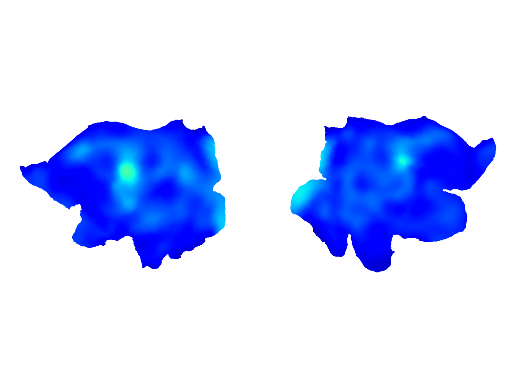

In [5]:
cifti_img = nb.load(gl.conn_dir + f'/maps/{traindata}_{cortex_roi}_{method}_{stats}.dscalar.nii')
plt.subplot(1,2,1)
ffpl.plot_cortex(cifti_img,hem='L',cscale=[0,0.05])
plt.subplot(1,2,2)
ffpl.plot_cortex(cifti_img,hem='R',cscale=[0,0.05])

# Make the cortical maps for specific cerebellar regions

In [6]:
# Make a nifti for the structure of interest
A= nb.load(f'{gl.atlas_dir}/tpl-MNI152NLin2009cSymC/atl-Anatom_space-MNI152NLin2009cSymC_dseg.nii')
X = A.get_fdata()
ROI = np.uint8((X==26) | (X==28))
roi_img = nb.Nifti1Image(ROI,A.affine)
# nb.save(roi_img,'roi_floculus.nii')



In [11]:
# Get the model 
model,_ = cs.get_model(traindata,cortex_roi,'L2Reg','sc_A2_global',norm=True,ynorm=True)
cifti_img =  cs.avrg_weight_map_roi(model,cerebellum_roi=roi_img)
fname = gl.conn_dir + f'/maps/floculus_L2Reg.pscalar.nii'
nb.save(cifti_img,fname)


In [16]:
fname = 'floculus_L2Reg.pscalar.nii'
oname = 'floculus_L2Reg.dscalar.nii'
cs.pscalar_to_smoothed_dscalar(fname,oname,sigma=10.0)

wb_command -cifti-smoothing 'temp.dscalar.nii' 10.0 0.0 COLUMN /Volumes/diedrichsen_data$/data/Cerebellum/connectivity/maps/floculus_L2Reg.dscalar.nii -left-surface /Volumes/diedrichsen_data$/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-L_inflated.surf.gii -right-surface /Volumes/diedrichsen_data$/data/FunctionalFusion_new/Atlases/tpl-fs32k/tpl-fs32k_hemi-R_inflated.surf.gii


<Axes: >

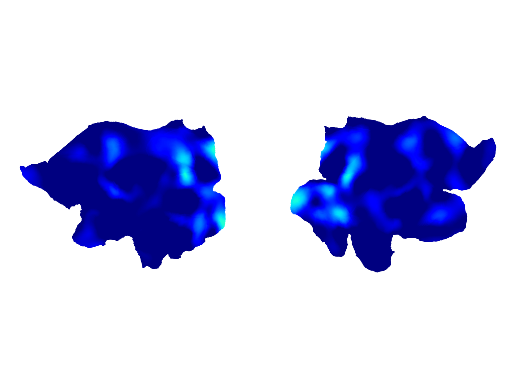

In [17]:
cifti_img = nb.load(gl.conn_dir + f'/maps/floculus_L2Reg.dscalar.nii')
plt.subplot(1,2,1)
ffpl.plot_cortex(cifti_img,hem='L',cscale=[0,0.05])
plt.subplot(1,2,2)
ffpl.plot_cortex(cifti_img,hem='R',cscale=[0,0.05])